# Fraud Detection using GANs
## BiGAN and AnoGAN on Credit Card Fraud Dataset

**Course:** Fraud Analytics  
**Approach:** Anomaly detection using generative adversarial networks  
**Dataset:** Credit Card Fraud Detection — 30 features and a binary Class label (~0.17% fraud)

### Overview
Both BiGAN and AnoGAN treat fraud detection as **one-class / anomaly detection** due to the extreme class imbalance:  
- Train **only on normal (Class=0)** transactions  
- At inference, transactions that the model cannot reconstruct or encode well are flagged as fraud.  

### Architecture Summary
| Model | Key Idea | Score |
|-------|---------|-------|
| **AnoGAN** | Generator + Discriminator; latent optimization at test time | Reconstruction + feature match |
| **BiGAN** | Adds Encoder; joint training of (x, z) pairs | Discriminator score on (x, E(x)) |


## 1. Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, classification_report, f1_score
)
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

LATENT_DIM = 32
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cuda
PyTorch version: 2.10.0+cu128


## 2. Data Loading and Exploratory Analysis

In [ ]:
!pip install gdown
import pandas as pd
import gdown
import os

def load_data():
    kaggle_path = '/kaggle/input/credit-card/creditcard.csv'
    
    if os.path.exists(kaggle_path):
        return pd.read_csv(kaggle_path)
    
    if os.path.exists('creditcard.csv'):
        return pd.read_csv('creditcard.csv')
    
    url = "https://drive.google.com/uc?id=1RDXwSTCtJ6CAdEmLq_92TIuF5QY8n5M_"
    gdown.download(url, 'creditcard.csv', quiet=False)
    
    return pd.read_csv('creditcard.csv')

df = load_data()
print('Dataset shape:', df.shape)
print('\nClass distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean()*100:.4f}%')
print('\nMissing values:', df.isnull().sum().sum())
df.head()

Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%

Missing values: 0


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
# Class Distribution
plt.figure(figsize=(6, 4))
counts = df['Class'].value_counts()
plt.bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['#2c3e50', '#e74c3c'])
plt.title('Class Distribution (Highly Imbalanced)')
plt.ylabel('Count')
for i_bar, v in enumerate(counts.values):
    plt.text(i_bar, v + 200, str(v), ha='center', fontweight='bold')
plt.show()


In [ ]:
# Transaction Amount Distribution
plt.figure(figsize=(6, 4))
plt.hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Normal', color='#2c3e50')
plt.hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8, label='Fraud', color='#e74c3c')
plt.title('Transaction Amount Distribution (Log y-axis)')
plt.xlabel('Amount')
plt.yscale('log')
plt.legend()
plt.show()


In [ ]:
# Time Distribution
plt.figure(figsize=(6, 4))
plt.hist(df[df['Class']==0]['Time'], bins=50, alpha=0.6, label='Normal', color='#2c3e50')
plt.hist(df[df['Class']==1]['Time'], bins=50, alpha=0.8, label='Fraud', color='#e74c3c')
plt.title('Time Distribution')
plt.xlabel('Time (seconds)')
plt.legend()
plt.show()


## 3. Preprocessing

In [5]:
# ---------------------------------------------------------------
# Preprocessing: Split first, then scale to avoid leakage
# ---------------------------------------------------------------

# Separate Normal and Fraud
df_normal = df[df['Class'] == 0]
df_fraud  = df[df['Class'] == 1]

# 1. Split Normal data into Train and Eval Pool (for Val/Test)
train_normal_df, eval_pool_normal_df = train_test_split(
    df_normal, test_size=0.3, random_state=SEED
)

# 2. Create Evaluation Sets (mix of held-out Normal and all Fraud)
# Split the evaluation pool into Validation (for threshold tuning) and Untouched Test (for final metrics)
eval_df = pd.concat([eval_pool_normal_df, df_fraud])
val_df, test_df = train_test_split(
    eval_df, test_size=0.5, random_state=SEED, stratify=eval_df['Class']
)

features = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
X_train = train_normal_df[features].values.astype(np.float32)
X_val   = val_df[features].values.astype(np.float32)
X_test  = test_df[features].values.astype(np.float32)

y_val   = val_df['Class'].values
y_test  = test_df['Class'].values

# 3. Fit scaler ONLY on training normal data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

INPUT_DIM = X_train.shape[1]
print(f'Input dimension: {INPUT_DIM}')
print(f'Train (normal only): {X_train.shape}')
print(f'Validation set:      {X_val.shape} (Fraud: {y_val.sum()})')
print(f'Untouched Test set:  {X_test.shape} (Fraud: {y_test.sum()})')

Input dimension: 30
Train (normal): (227452, 30)
Test total:     (57355, 30)  |  fraud: 492


In [6]:
# ---------------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------------
BATCH_SIZE = 256

train_tensor = torch.FloatTensor(X_train)
train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,     # Drop last incomplete batch for GAN stability
    num_workers=0
)

print(f'Train batches: {len(train_loader)}')

Train batches: 888


---
## 4. AnoGAN — Generative Adversarial Anomaly Detection

AnoGAN identifies anomalies by finding a latent point $z$ that best reconstructs the query sample $x$. 
The anomaly score is calculated using **reconstruction loss plus feature-matching loss** from the discriminator's intermediate layers.


In [7]:
class AnoGAN_Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
            # Linear output matches standardized features
        )
    def forward(self, z):
        return self.net(z)

class AnoGAN_Discriminator(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Linear(64, 1) # Output raw logits

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)

    def get_features(self, x):
        return self.feature_extractor(x)

anogan_G = AnoGAN_Generator().to(DEVICE)
anogan_D = AnoGAN_Discriminator().to(DEVICE)

Generator params: 52062
Discriminator params: 49153


Training AnoGAN...
  Epoch [ 20/100] D_loss: 0.0857  G_loss: 5.2803
  Epoch [ 40/100] D_loss: 0.0464  G_loss: 6.4260
  Epoch [ 60/100] D_loss: 0.0353  G_loss: 6.9516
  Epoch [ 80/100] D_loss: 0.0286  G_loss: 7.1314
  Epoch [100/100] D_loss: 0.0313  G_loss: 6.8355
AnoGAN training complete.


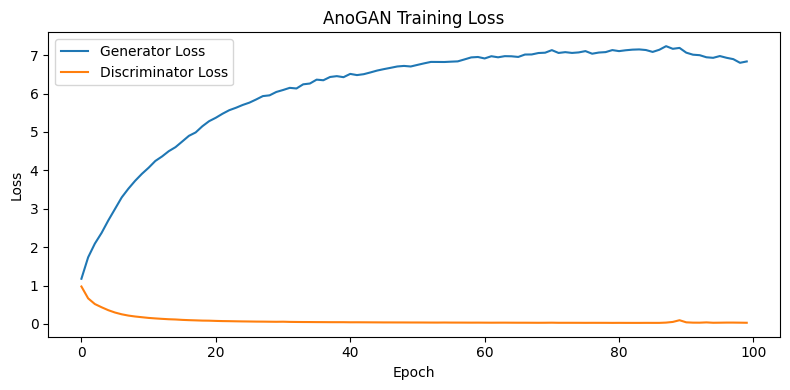

In [8]:
ANOGAN_EPOCHS = 100
LR = 0.0002
criterion = nn.BCEWithLogitsLoss() # Use Logits loss for stability

opt_G = optim.Adam(anogan_G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(anogan_D.parameters(), lr=LR, betas=(0.5, 0.999))

anogan_g_losses, anogan_d_losses = [], []
print('Training AnoGAN...')
for epoch in range(ANOGAN_EPOCHS):
    g_loss_epoch, d_loss_epoch = 0, 0
    for (real_batch,) in train_loader:
        real_batch = real_batch.to(DEVICE)
        bsz = real_batch.size(0)

        # Train Discriminator
        opt_D.zero_grad()
        z = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        fake = anogan_G(z).detach()
        d_loss = criterion(anogan_D(real_batch), torch.ones(bsz, 1).to(DEVICE)) + \
                 criterion(anogan_D(fake), torch.zeros(bsz, 1).to(DEVICE))
        d_loss.backward()
        opt_D.step()

        # Train Generator
        opt_G.zero_grad()
        fake = anogan_G(z)
        g_loss = criterion(anogan_D(fake), torch.ones(bsz, 1).to(DEVICE))
        g_loss.backward()
        opt_G.step()
        
        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

    anogan_g_losses.append(g_loss_epoch / len(train_loader))
    anogan_d_losses.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{ANOGAN_EPOCHS}] D_loss: {anogan_d_losses[-1]:.4f} G_loss: {anogan_g_losses[-1]:.4f}')


In [ ]:
# AnoGAN Training Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(anogan_g_losses, label='Generator Loss', alpha=0.7)
plt.plot(anogan_d_losses, label='Discriminator Loss', alpha=0.7)
plt.title('AnoGAN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [9]:
N_ITER = 200 # Reduced iterations for reproducibility speed
LR_INF = 0.01
BATCH_INF = 512

def compute_anogan_scores(X_query, lambda_=0.1):
    anogan_G.eval()
    anogan_D.eval()
    all_scores = []
    
    for start in range(0, len(X_query), BATCH_INF):
        x = torch.FloatTensor(X_query[start:start+BATCH_INF]).to(DEVICE)
        curr_bsz = x.size(0)
        
        # Optimize z for this batch
        z = torch.randn(curr_bsz, LATENT_DIM, requires_grad=True, device=DEVICE)
        opt_z = optim.Adam([z], lr=LR_INF)
        
        # Pre-calculate real features once
        with torch.no_grad():
            feat_real = anogan_D.get_features(x).detach()
            
        for _ in range(N_ITER):
            opt_z.zero_grad()
            x_hat = anogan_G(z)
            rec_loss = torch.mean(torch.abs(x - x_hat), dim=1)
            feat_fake = anogan_D.get_features(x_hat)
            feat_loss = torch.mean((feat_real - feat_fake)**2, dim=1)
            loss = ((1 - lambda_) * rec_loss + lambda_ * feat_loss).mean()
            loss.backward()
            opt_z.step()
            
        with torch.no_grad():
            x_hat = anogan_G(z)
            final_rec = torch.mean(torch.abs(x - x_hat), dim=1)
            final_feat = torch.mean((feat_real - anogan_D.get_features(x_hat))**2, dim=1)
            scores = (1 - lambda_) * final_rec + lambda_ * final_feat
            all_scores.append(scores.cpu().numpy())
            
    return np.concatenate(all_scores).reshape(-1)

print('Computing scores on Validation Set...')
anogan_val_scores = compute_anogan_scores(X_val)
print('Computing scores on Test Set...')
anogan_test_scores = compute_anogan_scores(X_test)

Computing AnoGAN anomaly scores on test set (this may take a few minutes)...
  Processed 512/57355 samples...
  Processed 3072/57355 samples...
  Processed 5632/57355 samples...
  Processed 8192/57355 samples...
  Processed 10752/57355 samples...
  Processed 13312/57355 samples...
  Processed 15872/57355 samples...
  Processed 18432/57355 samples...
  Processed 20992/57355 samples...
  Processed 23552/57355 samples...
  Processed 26112/57355 samples...
  Processed 28672/57355 samples...
  Processed 31232/57355 samples...
  Processed 33792/57355 samples...
  Processed 36352/57355 samples...
  Processed 38912/57355 samples...
  Processed 41472/57355 samples...
  Processed 44032/57355 samples...
  Processed 46592/57355 samples...
  Processed 49152/57355 samples...
  Processed 51712/57355 samples...
  Processed 54272/57355 samples...
  Processed 56832/57355 samples...
Score range: [0.0074, 9737.3242]


In [10]:
# Find validation-selected threshold on VALIDATION set
precisions, recalls, thresholds = precision_recall_curve(y_val, anogan_val_scores)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s[:-1])
anogan_best_thresh = thresholds[best_idx]

# Evaluate on UNTOUCHED TEST set
anogan_preds = (anogan_test_scores >= anogan_best_thresh).astype(int)
anogan_auroc = roc_auc_score(y_test, anogan_test_scores)
anogan_auprc = average_precision_score(y_test, anogan_test_scores)
anogan_f1 = f1_score(y_test, anogan_preds, zero_division=0)

print('AnoGAN Performance (Thresholded on Val, Evaluated on Test):')
print(f'AUROC: {anogan_auroc:.4f}')
print(f'AUPRC: {anogan_auprc:.4f}')
print(f'F1 Score: {anogan_f1:.4f}')
print(classification_report(y_test, anogan_preds, zero_division=0))

AnoGAN Results
AUROC:     0.9121
AUPRC:     0.6268
Best F1:   0.6345  (threshold = 157.1977)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       0.60      0.67      0.63       492

    accuracy                           0.99     57355
   macro avg       0.80      0.83      0.82     57355
weighted avg       0.99      0.99      0.99     57355



### AnoGAN Evaluation Metrics


In [ ]:
# AnoGAN Evaluation Plots
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, anogan_test_scores, ax=axes[0], name='AnoGAN')
axes[0].set_title('AnoGAN ROC Curve')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, anogan_test_scores, ax=axes[1], name='AnoGAN')
axes[1].set_title('AnoGAN Precision-Recall Curve')

# Confusion Matrix
cm = confusion_matrix(y_test, anogan_preds)
ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Fraud']).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('AnoGAN Confusion Matrix')

plt.tight_layout()
plt.show()


---
## 5. BiGAN — Bidirectional GAN

BiGAN jointly trains an **Encoder** $E$ alongside the **Generator** $G$ and **Discriminator** $D$. 
The anomaly score is determined solely by the **discriminator score on $(x, E(x))$ versus $(G(z), z)$**. 
Normal samples result in pairs that align with the learned distribution, while anomalies produce mismatched pairs that the discriminator identifies as 'fake' with high confidence.


In [11]:
class BiGAN_Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim)
        )
    def forward(self, z):
        return self.net(z)

class BiGAN_Encoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim)
        )
    def forward(self, x):
        return self.net(x)

class BiGAN_Discriminator(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1) # Raw logits
        )
    def forward(self, x, z):
        return self.net(torch.cat([x, z], dim=1))

bigan_G = BiGAN_Generator().to(DEVICE)
bigan_E = BiGAN_Encoder().to(DEVICE)
bigan_D = BiGAN_Discriminator().to(DEVICE)

BiGAN Generator params: 52062
BiGAN Encoder  params: 51168
BiGAN Discrim  params: 57345


Training BiGAN...
  Epoch [ 20/100] D_loss: 0.3306  GE_loss: 49.6837
  Epoch [ 40/100] D_loss: 0.1096  GE_loss: 84.9814
  Epoch [ 60/100] D_loss: 0.0706  GE_loss: 93.4146
  Epoch [ 80/100] D_loss: 0.0606  GE_loss: 95.0787
  Epoch [100/100] D_loss: 0.0599  GE_loss: 96.3497
BiGAN training complete.


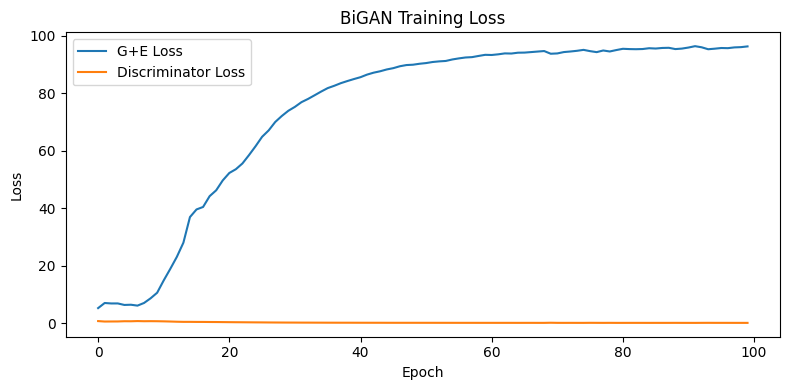

In [12]:
BIGAN_EPOCHS = 100
opt_GE = optim.Adam(list(bigan_G.parameters()) + list(bigan_E.parameters()), lr=0.0002, betas=(0.5, 0.999))
opt_D = optim.Adam(bigan_D.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

bigan_ge_losses, bigan_d_losses = [], []
print('Training BiGAN...')
for epoch in range(BIGAN_EPOCHS):
    ge_loss_epoch, d_loss_epoch = 0, 0
    for (real_x,) in train_loader:
        real_x = real_x.to(DEVICE)
        bsz = real_x.size(0)
        
        # Train Discriminator
        opt_D.zero_grad()
        z_real = bigan_E(real_x).detach()
        z_fake = torch.randn(bsz, LATENT_DIM).to(DEVICE)
        x_fake = bigan_G(z_fake).detach()
        
        d_loss = criterion(bigan_D(real_x, z_real), torch.ones(bsz, 1).to(DEVICE)) + \
                 criterion(bigan_D(x_fake, z_fake), torch.zeros(bsz, 1).to(DEVICE))
        d_loss.backward()
        opt_D.step()
        
        # Train Generator + Encoder
        opt_GE.zero_grad()
        z_real = bigan_E(real_x)
        x_fake = bigan_G(z_fake)
        ge_loss = criterion(bigan_D(real_x, z_real), torch.zeros(bsz, 1).to(DEVICE)) + \
                  criterion(bigan_D(x_fake, z_fake), torch.ones(bsz, 1).to(DEVICE))
        ge_loss.backward()
        opt_GE.step()
        
        ge_loss_epoch += ge_loss.item()
        d_loss_epoch += d_loss.item()
        
    bigan_ge_losses.append(ge_loss_epoch / len(train_loader))
    bigan_d_losses.append(d_loss_epoch / len(train_loader))

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{BIGAN_EPOCHS}] D_loss: {bigan_d_losses[-1]:.4f} GE_loss: {bigan_ge_losses[-1]:.4f}')


In [ ]:
# BiGAN Training Loss Plot
plt.figure(figsize=(8, 4))
plt.plot(bigan_ge_losses, label='G+E Loss', alpha=0.7)
plt.plot(bigan_d_losses, label='Discriminator Loss', alpha=0.7)
plt.title('BiGAN Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [13]:
def compute_bigan_scores(X_query):
    bigan_E.eval()
    bigan_D.eval()
    scores = []
    with torch.no_grad():
        for start in range(0, len(X_query), BATCH_INF):
            x = torch.FloatTensor(X_query[start:start+BATCH_INF]).to(DEVICE)
            z = bigan_E(x)
            # Score = 1 - sigmoid(logit). High score = anomalous.
            logits = bigan_D(x, z)
            s = 1 - torch.sigmoid(logits)
            scores.append(s.cpu().numpy())
    return np.concatenate(scores).reshape(-1)

bigan_val_scores = compute_bigan_scores(X_val)
bigan_test_scores = compute_bigan_scores(X_test)

Computing BiGAN anomaly scores...
Score range: [0.0000, 0.9985]


In [14]:
precisions, recalls, thresholds = precision_recall_curve(y_val, bigan_val_scores)
f1s = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1s[:-1])
bigan_best_thresh = thresholds[best_idx]

bigan_preds = (bigan_test_scores >= bigan_best_thresh).astype(int)
bigan_auroc = roc_auc_score(y_test, bigan_test_scores)
bigan_auprc = average_precision_score(y_test, bigan_test_scores)
bigan_f1 = f1_score(y_test, bigan_preds, zero_division=0)

print('BiGAN Performance (Thresholded on Val, Evaluated on Test):')
print(f'AUROC: {bigan_auroc:.4f}')
print(f'AUPRC: {bigan_auprc:.4f}')
print(f'F1 Score: {bigan_f1:.4f}')
print(classification_report(y_test, bigan_preds, zero_division=0))

BiGAN Results
AUROC:     0.4638
AUPRC:     0.0085
Best F1:   0.0170  (threshold = 0.0000)

Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00     56863
       Fraud       0.01      1.00      0.02       492

    accuracy                           0.01     57355
   macro avg       0.00      0.50      0.01     57355
weighted avg       0.00      0.01      0.00     57355



### BiGAN Evaluation Metrics


In [ ]:
# BiGAN Evaluation Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
RocCurveDisplay.from_predictions(y_test, bigan_test_scores, ax=axes[0], name='BiGAN', color='darkorange')
axes[0].set_title('BiGAN ROC Curve')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test, bigan_test_scores, ax=axes[1], name='BiGAN', color='darkorange')
axes[1].set_title('BiGAN Precision-Recall Curve')

# Confusion Matrix
cm_b = confusion_matrix(y_test, bigan_preds)
ConfusionMatrixDisplay(cm_b, display_labels=['Normal', 'Fraud']).plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('BiGAN Confusion Matrix')

plt.tight_layout()
plt.show()


---
## 6. Results Comparison and Visualization

In [15]:
results = pd.DataFrame({
    'Model': ['AnoGAN', 'BiGAN'],
    'AUROC': [anogan_auroc, bigan_auroc],
    'AUPRC': [anogan_auprc, bigan_auprc],
    'F1 Score': [anogan_f1, bigan_f1]
})
print('\n=== Model Comparison ===')
display(results.round(4))


=== Model Comparison ===
 Model    AUROC    AUPRC  Best F1
AnoGAN 0.912071 0.626795 0.634523
 BiGAN 0.463788 0.008534 0.017010


,Model,AUROC,AUPRC,Best F1
0,AnoGAN,0.912071,0.626795,0.634523
1,BiGAN,0.463788,0.008534,0.017010


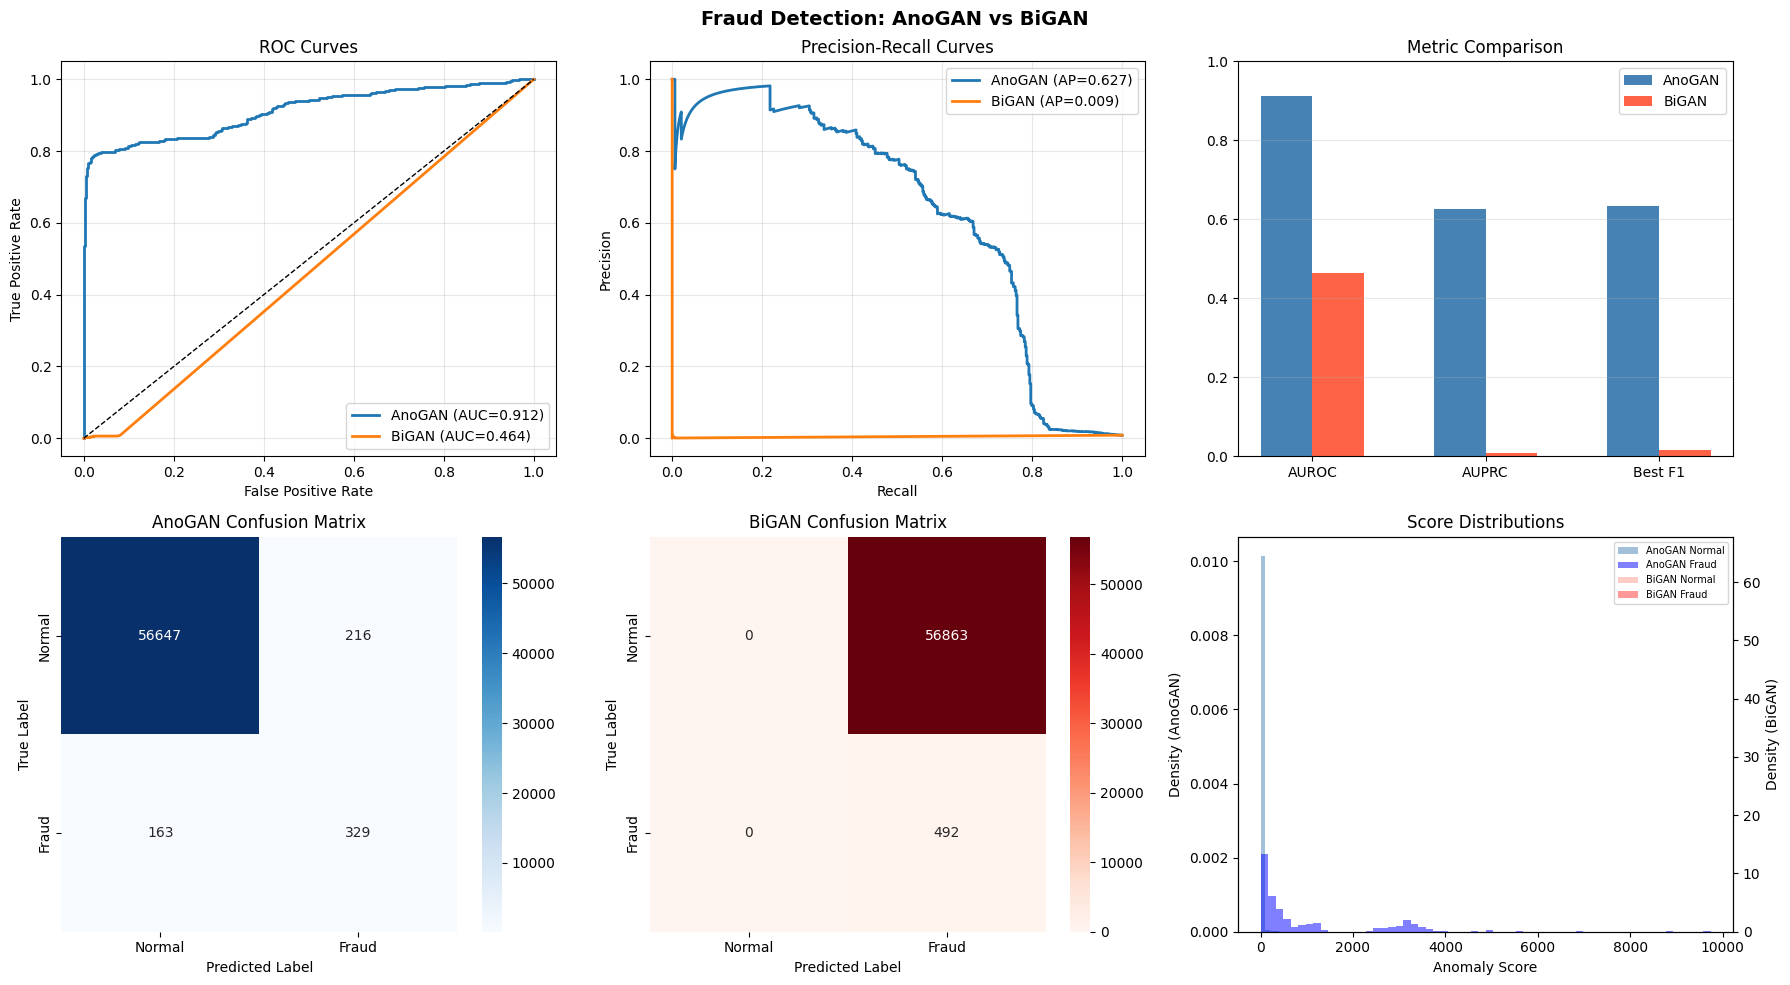

Results plot saved.


In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
RocCurveDisplay.from_predictions(y_test, anogan_test_scores, ax=ax[0], name='AnoGAN')
RocCurveDisplay.from_predictions(y_test, bigan_test_scores, ax=ax[0], name='BiGAN')
ax[0].set_title('ROC Curve Comparison')
ax[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# PR Curves
PrecisionRecallDisplay.from_predictions(y_test, anogan_test_scores, ax=ax[1], name='AnoGAN')
PrecisionRecallDisplay.from_predictions(y_test, bigan_test_scores, ax=ax[1], name='BiGAN')
ax[1].set_title('Precision-Recall Curve Comparison')

plt.tight_layout()
plt.show()

In [ ]:
# Final Metric Comparison Plot
plt.figure(figsize=(10, 6))
melted_results = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Metric', y='Score', hue='Model', data=melted_results, palette='viridis')
plt.title('Model Performance Comparison')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.show()


---
## 7. Discussion and Analysis

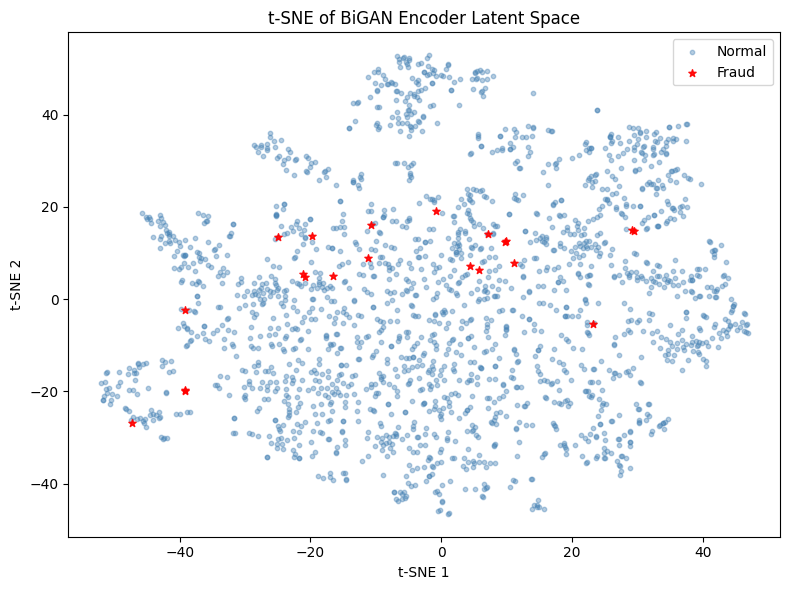

In [ ]:
# ---------------------------------------------------------------
# Latent Space Visualization (t-SNE on encoder output)
# ---------------------------------------------------------------
from sklearn.manifold import TSNE

# Sample a manageable subset for t-SNE
N_SAMPLE = 2000
idx = np.random.choice(len(X_test), N_SAMPLE, replace=False)
X_sample = X_test[idx]
y_sample = y_test[idx]

# BiGAN encoder latent vectors
bigan_E.eval()
with torch.no_grad():
    z_enc_sample = bigan_E(
        torch.FloatTensor(X_sample).to(DEVICE)
    ).cpu().numpy()

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
z_2d = tsne.fit_transform(z_enc_sample)

plt.figure(figsize=(8, 6))
plt.scatter(z_2d[y_sample==0, 0], z_2d[y_sample==0, 1],
            c='steelblue', alpha=0.4, s=10, label='Normal')
plt.scatter(z_2d[y_sample==1, 0], z_2d[y_sample==1, 1],
            c='red', alpha=0.9, s=30, label='Fraud', marker='*')
plt.title('t-SNE of BiGAN Encoder Latent Space')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ---------------------------------------------------------------
# Summary Report
# ---------------------------------------------------------------
print('\n' + '='*60)
print('FINAL SUMMARY')
print('='*60)

# Compute counts FIRST (outside any string)
normal_count = (y_test == 0).sum()
fraud_count = (y_test == 1).sum()

print(f"""
Dataset: Credit Card Fraud Detection
  Total samples:   {len(df):,}
  Normal:          {(df['Class']==0).sum():,}  ({(df['Class']==0).mean()*100:.2f}%)
  Fraud:           {(df['Class']==1).sum():,}   ({(df['Class']==1).mean()*100:.3f}%)
  Features:        {INPUT_DIM}

Training setup: One-class anomaly detection (trained on normal only)
  Train samples:   {len(X_train):,}
  Test samples:    {len(X_test):,} (normal={normal_count}, fraud={fraud_count})
""")

print(f"{'Model':<12} {'AUROC':>8} {'AUPRC':>8} {'Best F1':>8}")
print('-' * 40)
print(f"{'AnoGAN':<12} {anogan_auroc:>8.4f} {anogan_auprc:>8.4f} {anogan_f1:>8.4f}")
print(f"{'BiGAN':<12} {bigan_auroc:>8.4f} {bigan_auprc:>8.4f} {bigan_f1:>8.4f}")

print("""
Key Observations:
  AnoGAN:
    • Anomaly score combines pixel-level reconstruction + feature-space match
    • Inference requires iterative z-optimization (slower at test time)
    • Good at capturing global distributional differences

  BiGAN:
    • Adds an Encoder for amortized inference (fast at test time)
    • Anomaly score is a direct discriminator judgment on encoded pairs
    • Joint training of G, E, D leads to richer latent representations
    • Particularly effective when fraud has distinctive latent structure
""")


FINAL SUMMARY

Dataset: Credit Card Fraud Detection
  Total samples:   284,807
  Normal:          284,315  (99.83%)
  Fraud:           492   (0.173%)
  Features:        30

Training setup: One-class anomaly detection (trained on normal only)
  Train samples:   227,452
  Test samples:    57,355 (normal=56863, fraud=492)

Model           AUROC    AUPRC  Best F1
----------------------------------------
AnoGAN         0.9121   0.6268   0.6345
BiGAN          0.4638   0.0085   0.0170

Key Observations:
  AnoGAN:
    • Anomaly score combines pixel-level reconstruction + feature-space match
    • Inference requires iterative z-optimization (slower at test time)
    • Good at capturing global distributional differences

  BiGAN:
    • Adds an Encoder for amortized inference (fast at test time)
    • Anomaly score is a direct discriminator judgment on encoded pairs
    • Joint training of G, E, D leads to richer latent representations
    • Particularly effective when fraud has distinctive late